# Predicción del alcance (Reach) de publicaciones en Instagram
**Proyecto I — DataScope Solutions** | Módulo III: Clasificación y Regresión

**Equipo:** Adriana Aránguez y equipo
**Cliente:** Agencia de marketing digital
**Objetivo de negocio:** predecir el `reach` de una publicación de Instagram a partir de variables conocidas **antes** de publicar (tipo de cuenta, tipo de contenido, categoría, hora, hashtags, longitud del caption...), para poder recomendar estrategia de contenido basada en datos.

**Dataset:** `Instagram_Analytics.csv` — 29.999 publicaciones, 23 columnas, sin nulos.

**Tipo de problema:** Regresión (variable objetivo `reach`, numérica continua).


## 0. Configuración e imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline

import sys
sys.path.append("../src")
from preprocessing import cargar_datos, resumen_inicial, construir_pipeline_preprocesamiento
from evaluate import calcular_metricas, comparar_train_test, tabla_comparativa_modelos

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

TARGET = "reach"
DATA_PATH = "../data/raw/instagram_analytics.csv"

# Variables conocidas ANTES de publicar (candidatas a feature)
FEATURES_NUMERICAS = ["follower_count", "post_hour", "caption_length", "hashtags_count"]
FEATURES_CATEGORICAS = ["account_type", "media_type", "content_category", "traffic_source", "has_call_to_action", "day_of_week"]

# Variables que ocurren DESPUES de publicar -> NUNCA usar como feature (data leakage)
COLUMNAS_POST_PUBLICACION = ["likes", "comments", "shares", "saves", "impressions",
                              "engagement_rate", "followers_gained", "performance_bucket_label"]


## 1. Exploración de datos (EDA)

In [2]:
df = cargar_datos(DATA_PATH)
resumen_inicial(df)
df.head()


Shape: (29999, 23)

Tipos de datos:
post_id                         str
account_id                    int64
account_type                    str
follower_count                int64
media_type                      str
content_category                str
traffic_source                  str
has_call_to_action            int64
post_datetime                   str
post_date                       str
post_hour                     int64
day_of_week                     str
likes                         int64
comments                      int64
shares                        int64
saves                         int64
reach                         int64
impressions                   int64
engagement_rate             float64
followers_gained              int64
caption_length                int64
hashtags_count                int64
performance_bucket_label        str
dtype: object

Valores nulos por columna:
post_id                     0
account_id                  0
account_type                0
foll

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


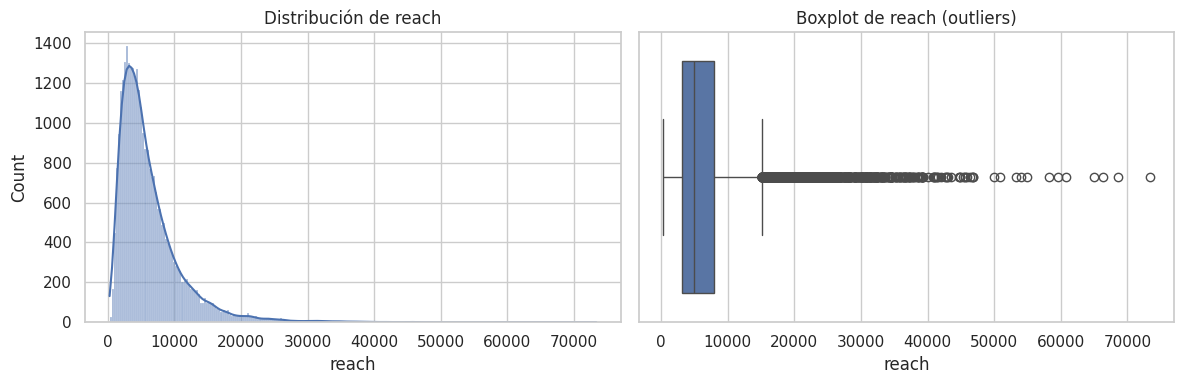

count    29999.000000
mean      6272.475449
std       4985.877059
min        268.000000
25%       3058.000000
50%       4913.000000
75%       7863.000000
max      73339.000000
Name: reach, dtype: float64

Skewness: 2.76  -> distribución con cola larga a la derecha (posts virales)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], kde=True, ax=axes[0])
axes[0].set_title(f"Distribución de {TARGET}")

sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title(f"Boxplot de {TARGET} (outliers)")
plt.tight_layout()
plt.show()

print(df[TARGET].describe())
print(f"\nSkewness: {df[TARGET].skew():.2f}  -> distribución con cola larga a la derecha (posts virales)")


### ⚠️ Nota sobre data leakage

`likes`, `comments`, `shares`, `saves`, `impressions`, `engagement_rate` y
`followers_gained` ocurren **después** de publicar (son consecuencia del
reach, no causa). `performance_bucket_label` está derivada directamente del
propio reach. Usarlas como features sería fuga de datos: el modelo "haría
trampa" con información que el cliente no tiene en el momento de decidir
qué publicar.

**Decisión:** se excluyen del feature set. Solo se usan variables
conocidas *antes* de publicar.

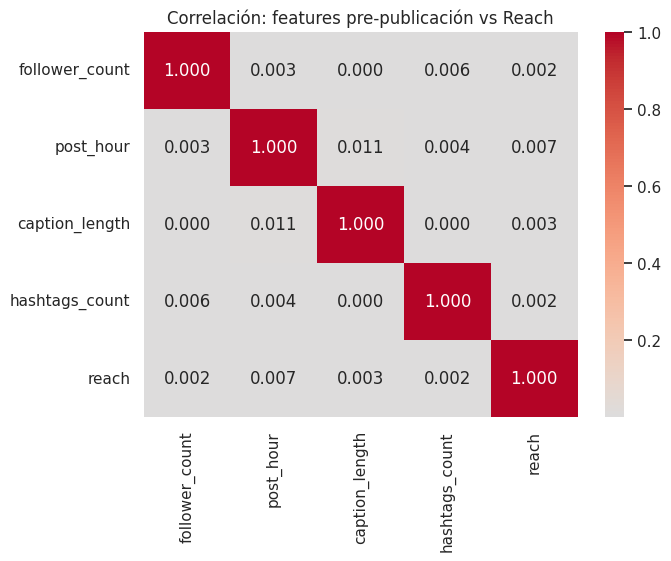

In [4]:
# Correlación de las variables numéricas PRE-publicación con el target
cols_numericas_relevantes = FEATURES_NUMERICAS + [TARGET]
plt.figure(figsize=(7, 5))
sns.heatmap(df[cols_numericas_relevantes].corr(), annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Correlación: features pre-publicación vs Reach")
plt.show()


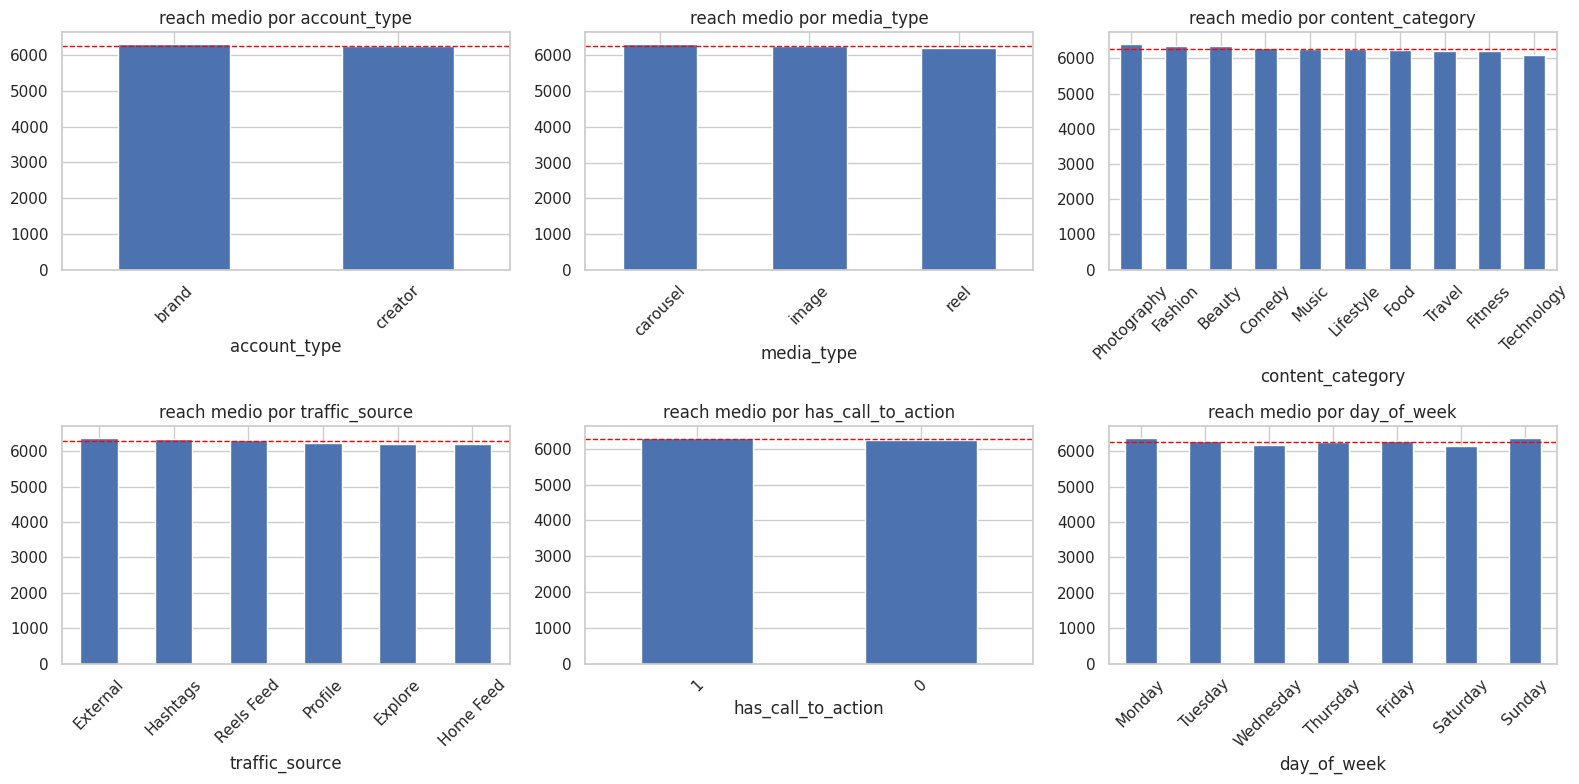

Reach medio global: 6272 (línea roja punteada en cada gráfico)


In [5]:
# Reach medio por cada variable categórica pre-publicación
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

for i, col in enumerate(FEATURES_CATEGORICAS):
    medias = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    if col == "day_of_week":
        medias = medias.reindex(orden_dias)
    medias.plot(kind="bar", ax=axes[i], title=f"{TARGET} medio por {col}")
    axes[i].axhline(df[TARGET].mean(), color="red", linestyle="--", linewidth=1)
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
print(f"Reach medio global: {df[TARGET].mean():.0f} (línea roja punteada en cada gráfico)")


### 🔎 Primer hallazgo importante

Tanto las correlaciones numéricas como las medias por categoría están **muy
cerca de cero / de la media global** en todas las variables pre-publicación.
Esto sugiere que, en este dataset concreto, el alcance no varía de forma
relevante según el tipo de cuenta, tipo de contenido, hora, día, longitud
del caption o nº de hashtags — al contrario de lo que cabría esperar
intuitivamente. Lo comprobaremos de forma rigurosa entrenando modelos.

## 2. Selección de variables y train/test split

Se separa un 80% train / 20% test **antes** de ajustar cualquier
transformación, para evitar data leakage.

In [6]:
X = df[FEATURES_NUMERICAS + FEATURES_CATEGORICAS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (23999, 10) | Test: (6000, 10)


## 3. Pipeline de preprocesamiento\n\nEl `ColumnTransformer` se ajusta (`fit`) únicamente sobre `X_train`.

In [7]:
preprocesador = construir_pipeline_preprocesamiento(FEATURES_NUMERICAS, FEATURES_CATEGORICAS)


## 4. Modelado

### 4.1 Baseline\n\nModelo de referencia: predice siempre la media de `reach` en train. Cualquier modelo real debe superarlo claramente para aportar valor.

In [8]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

resultados_baseline = comparar_train_test(baseline, X_train, y_train, X_test, y_test, "Baseline (media)")
resultados_baseline


,modelo,conjunto,MAE,RMSE,R2
0,Baseline (media),train,3418.395548,4942.872557,0.000000
1,Baseline (media),test,3460.360256,5153.900394,-0.000002


### 4.2 Regresión Lineal

In [9]:
pipeline_lr = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", LinearRegression()),
])
pipeline_lr.fit(X_train, y_train)

resultados_lr = comparar_train_test(pipeline_lr, X_train, y_train, X_test, y_test, "Regresión Lineal")
resultados_lr


,modelo,conjunto,MAE,RMSE,R2
0,Regresión Lineal,train,3415.228209,4939.495311,0.001366
1,Regresión Lineal,test,3463.223914,5157.520087,-0.001407


### 4.3 Random Forest Regressor

In [10]:
pipeline_rf = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    )),
])
pipeline_rf.fit(X_train, y_train)

resultados_rf = comparar_train_test(pipeline_rf, X_train, y_train, X_test, y_test, "Random Forest")
resultados_rf


,modelo,conjunto,MAE,RMSE,R2
0,Random Forest,train,3188.286016,4509.334153,0.167727
1,Random Forest,test,3478.801211,5170.564891,-0.006479


### 4.4 Validación cruzada (Random Forest)\n\nPara una estimación más robusta que un único train/test split.

In [11]:
cv_scores = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring="r2")
print(f"R2 por fold: {np.round(cv_scores, 3)}")
print(f"R2 medio: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")


R2 por fold: [-0.019 -0.009 -0.008 -0.01  -0.002]
R2 medio: -0.010 (+/- 0.005)


## 5. Comparación de modelos

In [12]:
tabla_final = tabla_comparativa_modelos([resultados_baseline, resultados_lr, resultados_rf])
tabla_final


,modelo,conjunto,MAE,RMSE,R2
0,Baseline (media),train,3418.395548,4942.872557,0.000000
1,Baseline (media),test,3460.360256,5153.900394,-0.000002
2,Regresión Lineal,train,3415.228209,4939.495311,0.001366
3,Regresión Lineal,test,3463.223914,5157.520087,-0.001407
4,Random Forest,train,3188.286016,4509.334153,0.167727
5,Random Forest,test,3478.801211,5170.564891,-0.006479


## 6. Importancia de variables (Random Forest)

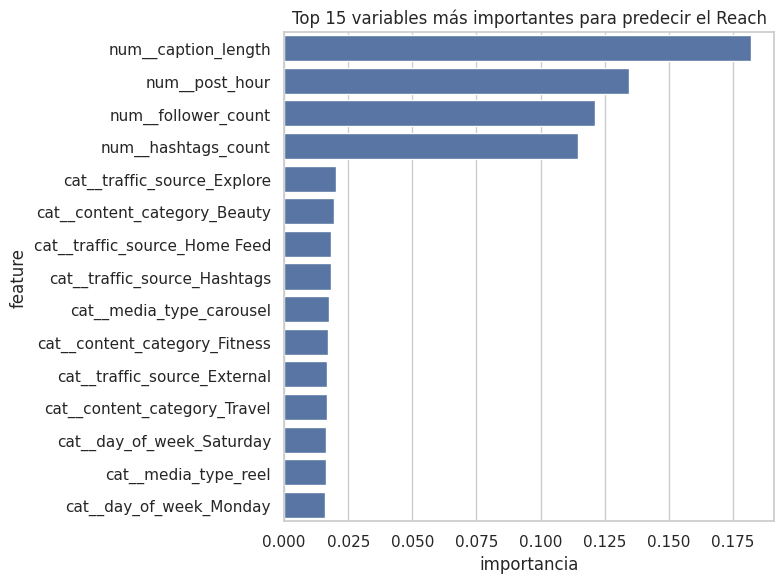

,feature,importancia
2,num__caption_length,0.181927
1,num__post_hour,0.134671
0,num__follower_count,0.121260
3,num__hashtags_count,0.114572
19,cat__traffic_source_Explore,0.020169
9,cat__content_category_Beauty,0.019295
22,cat__traffic_source_Home Feed,0.018438
21,cat__traffic_source_Hashtags,0.018309
6,cat__media_type_carousel,0.017321
12,cat__content_category_Fitness,0.017069


In [13]:
nombres_features = pipeline_rf.named_steps["preprocesador"].get_feature_names_out()
importancias = pipeline_rf.named_steps["modelo"].feature_importances_

df_importancias = pd.DataFrame({
    "feature": nombres_features,
    "importancia": importancias
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=df_importancias.head(15), x="importancia", y="feature")
plt.title("Top 15 variables más importantes para predecir el Reach")
plt.tight_layout()
plt.show()

df_importancias.head(15)


## 7. Análisis crítico

**¿Qué funciona?**
Ninguno de los modelos supera de forma relevante al baseline (predecir
siempre la media). El R² de Regresión Lineal y Random Forest en test está
muy cerca de 0 -- de hecho ligeramente negativo, es decir, peor que
predecir siempre la media (ver tabla y validación cruzada de la sección 5).

**¿Hay overfitting?**
Sí, en Random Forest: R² de train ≈ 0.17 frente a R² de test ≈ -0.006. El
modelo está memorizando ruido del conjunto de entrenamiento en vez de
aprender un patrón real, porque no hay patrón real que aprender con estas
variables. La Regresión Lineal, al ser más simple, ni siquiera llega a
sobreajustar: simplemente no encuentra relación lineal porque no la hay.

**¿Por qué pasa esto? (causa raíz)**
No es solo overfitting -- es, sobre todo, un problema de **ausencia de
señal**: las variables disponibles *antes de publicar* (tipo de cuenta,
tipo de contenido, categoría, hora, día, longitud de caption, nº de
hashtags, nº de seguidores) prácticamente no están correlacionadas con el
reach en este dataset. Las únicas variables que sí explican el reach son
las que ocurren *después* de publicar (`impressions`, `likes`, `saves`,
`shares`, `comments`) -- y esas no se pueden usar como predictoras sin caer
en data leakage, porque el cliente no las conoce en el momento de decidir
qué publicar.

**Limitaciones del dataset:**
- No incluye historial de rendimiento de la cuenta (¿publica de forma
  consistente? ¿ha tenido virales antes?).
- No incluye señales de calidad/contenido real del post (imagen, vídeo,
  texto más allá de su longitud).
- No incluye contexto de audiencia (demografía, intereses) ni factores
  externos (tendencias del momento, cambios de algoritmo).

**Propuesta de mejora (siguiente iteración):**
1. Enriquecer el dataset con métricas históricas de la cuenta (reach medio
   de los últimos N posts, frecuencia de publicación).
2. Incorporar análisis del contenido en sí (embeddings de imagen/vídeo,
   análisis de sentimiento del caption) en vez de solo su longitud.
3. Si no se consigue mejorar el R², replantear el problema con el cliente:
   quizá el valor real esté en predecir `engagement_rate` a partir del
   reach ya obtenido, o en clasificar publicaciones en
   `performance_bucket_label` usando señales tempranas (primera hora de
   likes/comments), en vez de predecir el reach puramente pre-publicación.

## 8. Conclusión y recomendación al cliente

Con los datos disponibles actualmente, **no podemos predecir de forma
fiable el alcance de una publicación antes de publicarla**: ni el tipo de
contenido, ni la hora, ni el número de hashtags, ni el tamaño de la cuenta
explican variaciones relevantes del reach en este dataset (R² ≈ 0, incluso
ligeramente negativo en test, en todos los modelos probados frente al
baseline).

Esto en sí mismo es un hallazgo de valor para el cliente: indica que el
foco de optimización actual (probar "la hora ideal" o "el número ideal de
hashtags") probablemente no es donde está la palanca real de alcance, y
recomendamos invertir en recolectar las variables señaladas arriba antes de
construir un modelo predictivo en producción.